In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

In [2]:
dataset= load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas() 

In [3]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [5]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US['salary_year_avg'].sample(10)

569475    137610.0
348803     70000.0
294721    140000.0
423941    165000.0
233781     84800.0
775450    131900.0
416410    170000.0
261082    170000.0
523321     72500.0
306947    115000.0
Name: salary_year_avg, dtype: float64

<Axes: >

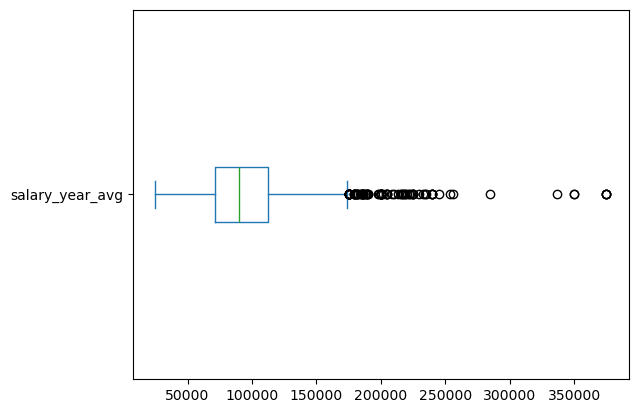

In [7]:
df_DA_US['salary_year_avg'].plot(kind='box' , vert=False)


/tmp/ipykernel_8289/3433996919.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x796adbe12190>,
 'caps': [<matplotlib.lines.Line2D at 0x796adbea7410>,
 'boxes': [<matplotlib.lines.Line2D at 0x796adbe12310>,
 'medians': [<matplotlib.lines.Line2D at 0x796adbe97910>,
 'fliers': [<matplotlib.lines.Line2D at 0x796adbe977d0>,
 'means': []}

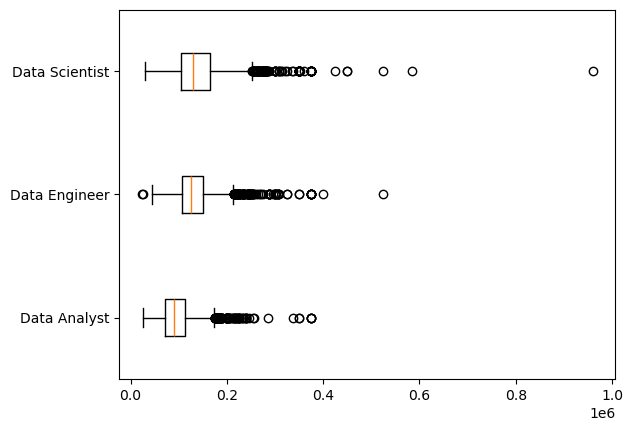

In [76]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)